# НИР: Выявление мошеннических транзакций методом MHSNet

**Тема:** Разработка метода выявления мошеннических транзакций с применением сети Хопфилда

**Пайплайн (по Zhao et al., SSRN 5335578 — MHSNet-SNN):**

```
Данные → Предобработка → Kernel PCA → LOF → Hopfield (MHS) → Классификация
```

Данный notebook воспроизводит все этапы работы с данными, содержит теоретические пояснения и выводы для научно-исследовательской работы.

---
## Содержание

1. [Теоретические основы](#1)
2. [Настройка окружения](#2)
3. [Загрузка и описание датасета](#3)
4. [Разведочный анализ данных (EDA)](#4)
5. [Предобработка и feature engineering](#5)
6. [Kernel PCA — нелинейное снижение размерности](#6)
7. [LOF — обнаружение локальных выбросов](#7)
8. [Сеть Хопфилда и Modern Hopfield Energy](#8)
9. [Обучение MHSNet и подбор порогов](#9)
10. [Эксперименты и сравнение с baseline](#10)
11. [Выводы](#11)

<a id="1"></a>
## 1. Теоретические основы

### 1.1. Постановка задачи

Пусть каждая транзакция описывается вектором признаков $\mathbf{x} \in \mathbb{R}^d$. Требуется построить функцию:

$$f(\mathbf{x}) \rightarrow \{0, 1\}, \quad 0\text{ — легитимная},\; 1\text{ — мошенническая}$$

**Сложности:**
- экстремальный **дисбаланс классов** (fraud < 1%);
- **concept drift** — схемы мошенничества меняются;
- необходимость **низкого FPR** (ложных блокировок).

### 1.2. Идея MHSNet (адаптация для НИР)

По Zhao et al. (2025, SSRN 5335578) эффективна **каскадная** схема:

| Этап | Метод | Роль |
|------|-------|------|
| 1 | Z-score / StandardScaler | Приведение признаков к единому масштабу |
| 2 | **Kernel PCA** | Извлечение нелинейных паттернов |
| 3 | **LOF** | Безучительное выделение аномалий по локальной плотности |
| 4 | **Hopfield MHS** | Ассоциативное восстановление + энергетический скор |

В нашей реализации SNN (спайковая сеть) из оригинальной статьи заменена на **классическую + Modern Hopfield Energy** — это упрощение, сохраняющее научную суть энергетического обнаружения выбросов.

<a id="2"></a>
## 2. Настройка окружения

In [1]:
# Добавляем корень проекта в sys.path, чтобы импортировать модули src/
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc

from src.config import ExperimentConfig, CAIXABANK_DIR, OUTPUT_DIR
from src.data_loader import prepare_data
from src.mhsnet_detector import MHSNetFraudDetector
from src.baselines import train_baselines, predict_baselines
from src.evaluation import compute_metrics, metrics_to_dataframe, recall_at_fpr

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
print(f"Корень проекта: {PROJECT_ROOT}")

Корень проекта: c:\my_work_repo\hopfield-network-for-fraud-nir


In [2]:
from src.config import CAIXABANK_DIR, KAGGLE_DATASET, OUTPUT_DIR

# Проверка наличия датасета CaixaBank (computingvictor / Kaggle)
required_files = [
    CAIXABANK_DIR / "transactions_data.csv",
    CAIXABANK_DIR / "cards_data.csv",
    CAIXABANK_DIR / "train_fraud_labels.json",
]

if not all(path.exists() for path in required_files):
    raise FileNotFoundError(
        f"Датасет не найден в {CAIXABANK_DIR}.\n"
        "Выполните в терминале из корня проекта:\n"
        "  python scripts/download_dataset.py\n\n"
        f"Источник: https://www.kaggle.com/datasets/{KAGGLE_DATASET}"
    )

config = ExperimentConfig(
    caixabank_dir=CAIXABANK_DIR,
    max_train_normal=30_000,
    balanced_eval_per_class=300,
    kpca_components=12,
    kpca_fit_max_samples=5_000,
    lof_neighbors=20,
    pipeline_mode="fusion",
    output_dir=OUTPUT_DIR / "notebook_run",
    random_state=42,
)

config.output_dir.mkdir(parents=True, exist_ok=True)
print(f"Датасет: {KAGGLE_DATASET}")
print(f"Путь:    {CAIXABANK_DIR}")
print(f"Kernel PCA: {config.use_kernel_pca}, LOF: {config.use_lof}")
print(f"Pipeline mode: {config.pipeline_mode}")

Датасет: computingvictor/transactions-fraud-datasets
Путь:    C:\my_work_repo\hopfield-network-for-fraud-nir\data\caixabank
Kernel PCA: True, LOF: True
Pipeline mode: fusion


<a id="3"></a>
## 3. Загрузка и описание датасета

### Датасет CaixaBank (computingvictor, Kaggle 2024)

- **transactions_data.csv** — ~13 млн транзакций (сумма, время, тип чипа, мерчант)
- **cards_data.csv** — данные карт (лимит, бренд, chip, dark web)
- **train_fraud_labels.json** — метки fraud (~13 332 случаев, ~0.1%)

**Теоретическое замечание:** в реальных банковских системах метки мошенничества задерживаются (chargeback), поэтому unsupervised-методы (LOF, Hopfield) ценны тем, что не требуют полной разметки при обучении памяти.

In [3]:
# Загрузка данных через единый пайплайн проекта
data = prepare_data(config)

print("=== Статистика загруженной выборки ===")
print(f"Признаков: {len(data['feature_names'])}")
print(f"Train: {len(data['y_train'])} | fraud: {data['y_train'].sum()} ({data['y_train'].mean():.2%})")
print(f"Val:   {len(data['y_val'])}   | fraud: {data['y_val'].sum()}")
print(f"Test:  {len(data['y_test'])}  | fraud: {data['y_test'].sum()}")

if data.get("metadata"):
    display(pd.Series(data["metadata"], name="metadata"))

=== Статистика загруженной выборки ===
Признаков: 21
Train: 29934 | fraud: 8934 (29.85%)
Val:   600   | fraud: 300
Test:  600  | fraud: 300


total_loaded               42763.000000
fraud_loaded               12763.000000
fraud_rate_loaded              0.298459
labeled_fraud_in_source    13332.000000
Name: metadata, dtype: float64

<a id="4"></a>
## 4. Разведочный анализ данных (EDA)

**Цель EDA:** понять дисбаланс классов, распределение признаков и обосновать необходимость специальных методов (LOF, сбалансированная оценка).

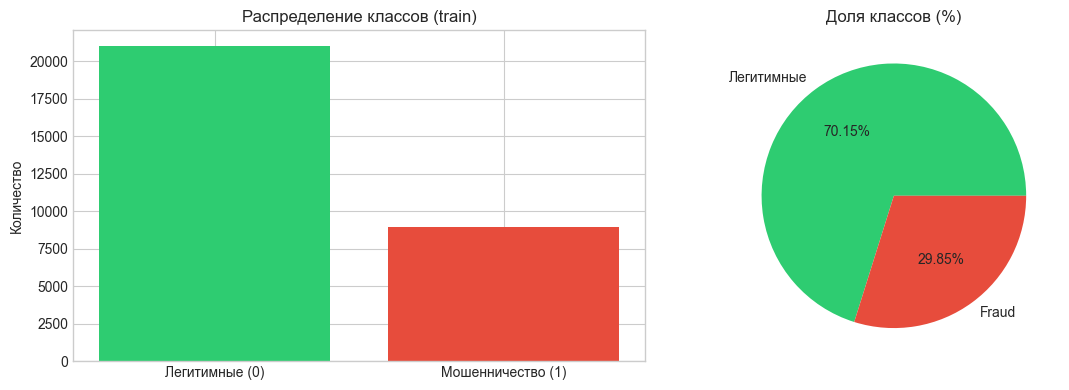


⚠ Дисбаланс: fraud составляет 29.8457% обучающей выборки.
  → Поэтому для оценки используем сбалансированные val/test и метрику Recall@FPR=5%.


In [4]:
# Распределение классов в обучающей выборке
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = pd.Series(data["y_train"]).value_counts().sort_index()
axes[0].bar(["Легитимные (0)", "Мошенничество (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Распределение классов (train)")
axes[0].set_ylabel("Количество")

# Доли в процентах (логарифмическая шкала для наглядности дисбаланса)
pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=["Легитимные", "Fraud"], autopct="%1.2f%%", colors=["#2ecc71", "#e74c3c"])
axes[1].set_title("Доля классов (%)")

plt.tight_layout()
plt.savefig(config.output_dir / "eda_class_distribution.png", dpi=150)
plt.show()

print(f"\n⚠ Дисбаланс: fraud составляет {data['y_train'].mean():.4%} обучающей выборки.")
print("  → Поэтому для оценки используем сбалансированные val/test и метрику Recall@FPR=5%.")

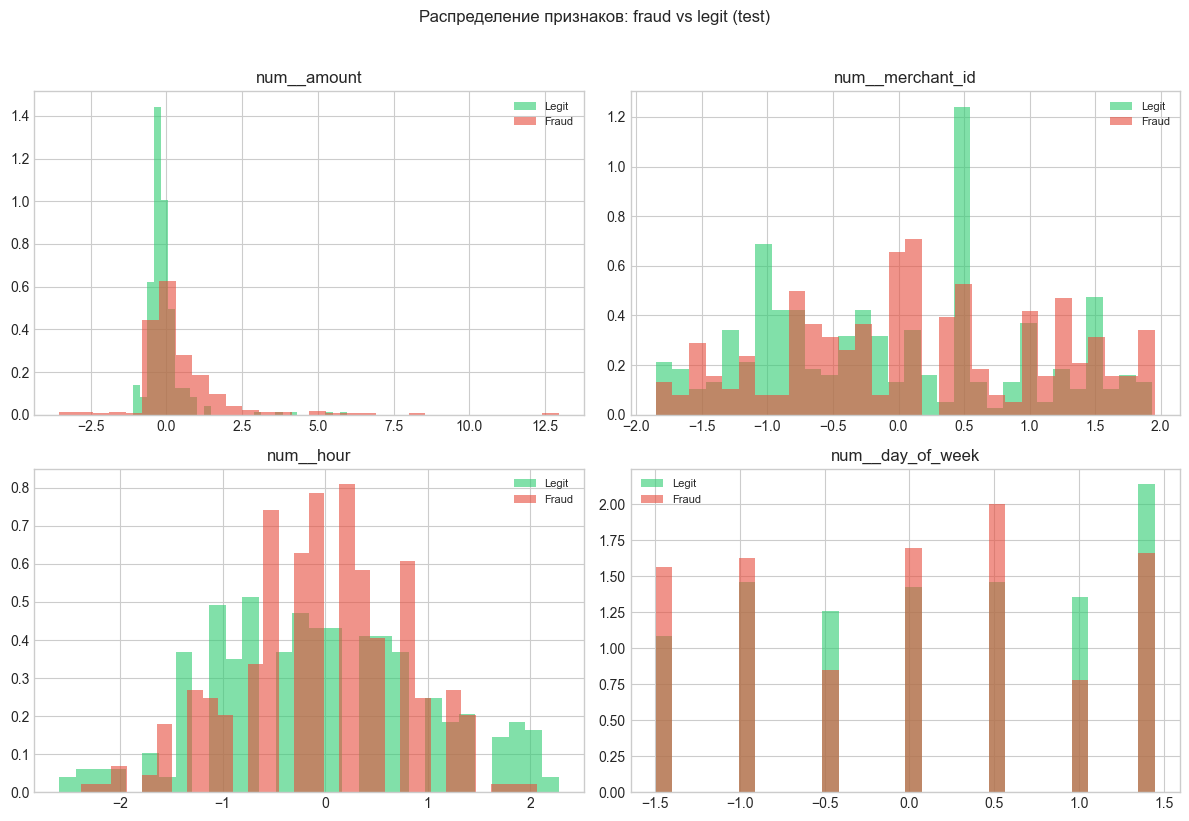

In [5]:
# Распределение первых числовых признаков по классам (на тесте)
X_test_df = pd.DataFrame(data["X_test"], columns=data["feature_names"])
X_test_df["is_fraud"] = data["y_test"]

plot_cols = list(X_test_df.columns[:4])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    for label, name, color in [(0, "Legit", "#2ecc71"), (1, "Fraud", "#e74c3c")]:
        subset = X_test_df.loc[X_test_df["is_fraud"] == label, col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=name, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Распределение признаков: fraud vs legit (test)", y=1.02)
plt.tight_layout()
plt.savefig(config.output_dir / "eda_feature_distributions.png", dpi=150)
plt.show()

### Вывод по EDA

- Классы **сильно несбалансированы** в полной выборке.
- Распределения признаков для fraud и legit **частично перекрываются** → нужны нелинейные методы (Kernel PCA) и локальные метрики аномальности (LOF).
- Accuracy как метрика **неинформативна** при дисбалансе; ориентируемся на F1, ROC-AUC, Recall@FPR=5%.

<a id="5"></a>
## 5. Предобработка и feature engineering

### Теория: Z-score нормализация

По формуле из статьи Zhao et al. (2025):

$$v' = \frac{v - \mu}{\sigma}$$

где $\mu$ — среднее признака, $\sigma$ — стандартное отклонение.

**Зачем:** признаки (сумма транзакции, ID мерчанта, лимит карты) имеют разные масштабы. Без нормализации LOF и Hopfield будут доминироваться одним-двумя признаками.

В проекте нормализация выполняется в `caixabank_loader.py` через `StandardScaler` + `OneHotEncoder` для категориальных признаков.

In [6]:
# Проверка: признаки уже стандартизированы (mean ≈ 0, std ≈ 1 на train)
X_train = data["X_train"]
stats = pd.DataFrame({
    "mean": X_train.mean(axis=0),
    "std": X_train.std(axis=0),
}, index=data["feature_names"])

print("Статистика признаков после StandardScaler (первые 8):")
display(stats.head(8).round(3))
print("\n✓ Признаки приведены к сопоставимому масштабу — готовы для Kernel PCA.")

Статистика признаков после StandardScaler (первые 8):


,mean,std
num__amount,-0.003,0.988
num__merchant_id,-0.004,0.999
num__hour,-0.000,1.002
num__day_of_week,0.001,1.001
num__month,0.003,1.001
num__num_cards_issued,0.001,1.001
num__credit_limit,-0.001,0.994
num__year_pin_last_changed,0.001,1.003



✓ Признаки приведены к сопоставимому масштабу — готовы для Kernel PCA.


<a id="6"></a>
## 6. Kernel PCA — нелинейное снижение размерности

### Теория

**Kernel PCA** (Schölkopf et al., 1998) обобщает PCA на нелинейный случай через ядерный трюк:

1. Данные $\mathbf{w}_l$ отображаются в пространство признаков $\varphi(\mathbf{w})$
2. В этом пространстве выполняется PCA
3. Ядро $K(\mathbf{w}_i, \mathbf{w}_j) = \varphi(\mathbf{w}_i)^\top \varphi(\mathbf{w}_j)$ позволяет не вычислять $\varphi$ явно

Для RBF-ядра: $K(\mathbf{x}, \mathbf{y}) = \exp(-\gamma \|\mathbf{x} - \mathbf{y}\|^2)$

**Зачем в fraud detection:** мошеннические транзакции часто лежат на **нелинейных многообразиях** в пространстве признаков. Линейный PCA их не разделяет, Kernel PCA — может.

> *Из статьи Zhao et al.: «Kernel PCA is used to reduce dimensionality and capture significant nonlinear patterns».*

In [7]:
from src.feature_pipeline import KernelPCAExtractor

kpca = KernelPCAExtractor(
    n_components=config.kpca_components,
    kernel=config.kpca_kernel,
    fit_max_samples=config.kpca_fit_max_samples,
    random_state=config.random_state,
)

X_train_kpca = kpca.fit_transform(data["X_train"])
X_test_kpca = kpca.transform(data["X_test"])

print(f"Исходная размерность: {data['X_train'].shape[1]}")
print(f"После Kernel PCA:      {X_train_kpca.shape[1]}")
print(f"Обучение KPCA на подвыборке ≤ {config.kpca_fit_max_samples} точек (ускорение)")

Исходная размерность: 21
После Kernel PCA:      12
Обучение KPCA на подвыборке ≤ 5000 точек (ускорение)


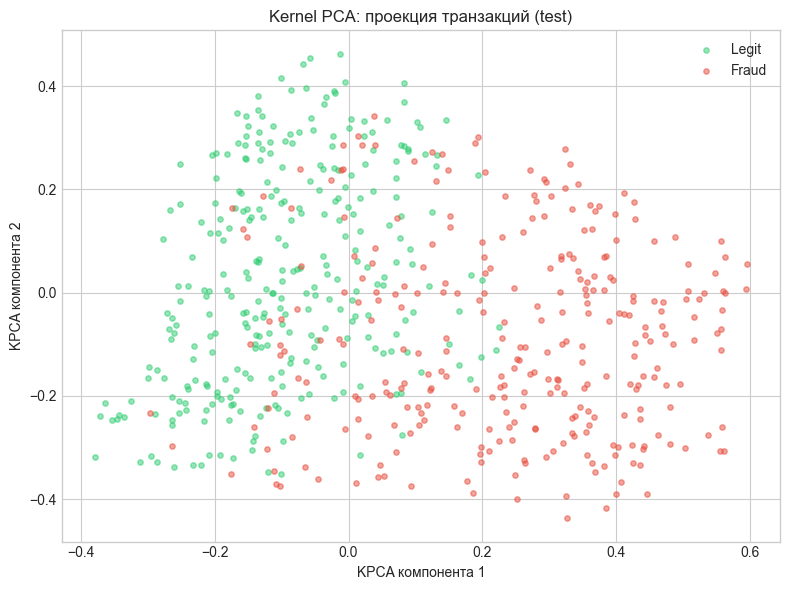


Наблюдение: fraud-точки часто образуют отдельные «облака» в пространстве KPCA,
что подтверждает целесообразность нелинейного снижения размерности.


In [8]:
# Визуализация: первые 2 компоненты Kernel PCA
fig, ax = plt.subplots(figsize=(8, 6))

for label, name, color in [(0, "Legit", "#2ecc71"), (1, "Fraud", "#e74c3c")]:
    mask = data["y_test"] == label
    ax.scatter(
        X_test_kpca[mask, 0], X_test_kpca[mask, 1],
        alpha=0.5, s=15, label=name, color=color,
    )

ax.set_xlabel("KPCA компонента 1")
ax.set_ylabel("KPCA компонента 2")
ax.set_title("Kernel PCA: проекция транзакций (test)")
ax.legend()
plt.tight_layout()
plt.savefig(config.output_dir / "kpca_scatter.png", dpi=150)
plt.show()

print("\nНаблюдение: fraud-точки часто образуют отдельные «облака» в пространстве KPCA,")
print("что подтверждает целесообразность нелинейного снижения размерности.")

<a id="7"></a>
## 7. LOF — Local Outlier Factor

### Теория (Breunig et al., 2000)

**LOF** сравнивает локальную плотность точки с плотностью её $k$ ближайших соседей:

$$\text{LOF}_k(\mathbf{x}) = \frac{\sum_{o \in N_k(\mathbf{x})} \text{lrd}_k(o)}{|N_k(\mathbf{x})| \cdot \text{lrd}_k(\mathbf{x})}$$

- $\text{LOF} \approx 1$ — точка в нормальной зоне плотности
- $\text{LOF} \gg 1$ — **выброс** (локальная плотность ниже, чем у соседей)

**В нашем пайплайне:** LOF обучается **только на нормальных** транзакциях (unsupervised). Высокий LOF-score → кандидат в мошенники.

> *Из статьи Zhao et al.: «LOF is used to detect anomalous transactions that depart from conventional patterns in an unsupervised manner».*

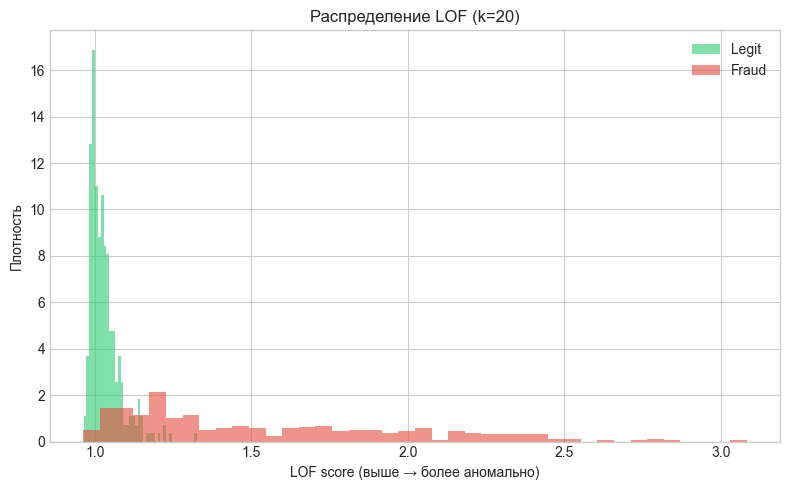

In [9]:
from sklearn.neighbors import LocalOutlierFactor

normal_mask = data["y_train"] == 0
lof = LocalOutlierFactor(
    n_neighbors=config.lof_neighbors,
    contamination=config.lof_contamination,
    novelty=True,
    n_jobs=-1,
)
lof.fit(X_train_kpca[normal_mask])

# score_samples: чем меньше — тем более аномальна точка; инвертируем
lof_scores_test = -lof.score_samples(X_test_kpca)

fig, ax = plt.subplots(figsize=(8, 5))
for label, name, color in [(0, "Legit", "#2ecc71"), (1, "Fraud", "#e74c3c")]:
    mask = data["y_test"] == label
    ax.hist(lof_scores_test[mask], bins=40, alpha=0.6, label=name, color=color, density=True)

ax.set_xlabel("LOF score (выше → более аномально)")
ax.set_ylabel("Плотность")
ax.set_title(f"Распределение LOF (k={config.lof_neighbors})")
ax.legend()
plt.tight_layout()
plt.savefig(config.output_dir / "lof_distribution.png", dpi=150)
plt.show()

### Вывод по LOF

- LOF **разделяет** распределения fraud и legit по хвостам.
- Метод не требует меток мошенничества при обучении — только нормальные транзакции.
- Ограничение: LOF чувствителен к выбору $k$ и масштабу данных (поэтому перед LOF — Kernel PCA).

<a id="8"></a>
## 8. Сеть Хопфилда и Modern Hopfield Energy

### 8.1. Классическая сеть Хопфилда (1982)

Рекуррентная сеть с **ассоциативной памятью**. Обучение по правилу Хебба:

$$w_{ij} = \frac{1}{N}\sum_{\mu=1}^{N} \xi_i^{\mu} \xi_j^{\mu}, \quad w_{ii} = 0$$

Восстановление образа итерациями до сходимости. **Ошибка восстановления** $\|\mathbf{x} - \hat{\mathbf{x}}\|$ — мера «чуждости» транзакции.

### 8.2. Modern Hopfield Energy (Ramsauer et al., 2021)

$$E(\boldsymbol{\xi}) = -\text{logsumexp}(\beta \cdot W \boldsymbol{\xi}) + \frac{1}{2}\|\boldsymbol{\xi}\|^2$$

- **Низкая энергия** → транзакция близка к сохранённым нормальным прототипам
- **Высокая энергия** → outlier / fraud

### 8.3. Гибридный скор MHS

$$S_{MHS} = 0.35 \cdot \hat{R} + 0.20 \cdot \hat{D} + 0.45 \cdot \hat{E}$$

где $\hat{R}$ — ошибка восстановления, $\hat{D}$ — расстояние до ближайшего прототипа, $\hat{E}$ — нормированная энергия.

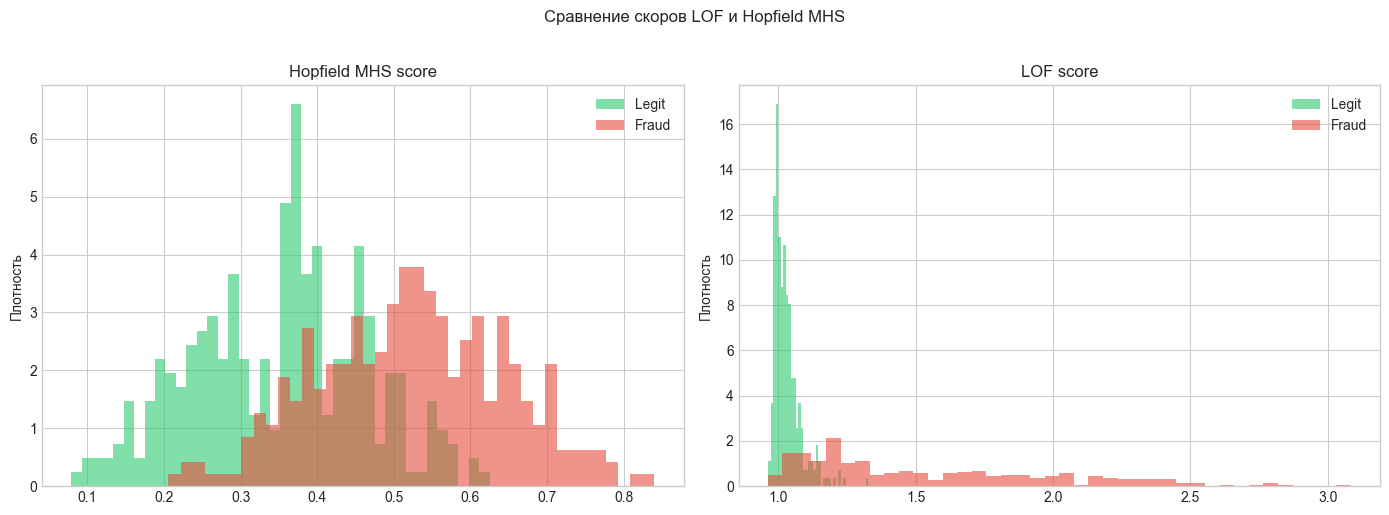

In [10]:
# Демонстрация: энергия и ошибка восстановления на тесте
detector = MHSNetFraudDetector(config)
detector.fit(data["X_train"], data["y_train"])

hopfield_scores = detector.hopfield_scores(data["X_test"])
lof_scores = detector.lof_scores(data["X_test"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name, color in [(0, "Legit", "#2ecc71"), (1, "Fraud", "#e74c3c")]:
    mask = data["y_test"] == label
    axes[0].hist(hopfield_scores[mask], bins=40, alpha=0.6, label=name, color=color, density=True)
    axes[1].hist(lof_scores[mask], bins=40, alpha=0.6, label=name, color=color, density=True)

axes[0].set_title("Hopfield MHS score")
axes[1].set_title("LOF score")
for ax in axes:
    ax.legend()
    ax.set_ylabel("Плотность")

plt.suptitle("Сравнение скоров LOF и Hopfield MHS", y=1.02)
plt.tight_layout()
plt.savefig(config.output_dir / "lof_vs_hopfield.png", dpi=150)
plt.show()

<a id="9"></a>
## 9. Обучение MHSNet и подбор порогов

### Итоговый скор (режим fusion)

$$S_{final} = w_{LOF} \cdot \widehat{LOF} + w_{MHS} \cdot \widehat{MHS}, \quad w_{LOF}=0.35,\; w_{MHS}=0.65$$

Порог $\theta$ подбирается на **валидационной** выборке по F1.

### Режим cascade (как в статье)

1. LOF отбирает подозрительные транзакции
2. Hopfield классифицирует только их

Переключение: `config.pipeline_mode = "cascade"`

In [11]:
# Подбор порогов на валидации
lof_gate, threshold = detector.tune_thresholds(
    data["X_val"], data["y_val"], metric=config.threshold_metric
)

print(f"LOF gate threshold: {lof_gate:.4f}")
print(f"Final threshold:     {threshold:.4f}")
print(f"Прототипов Hopfield: {len(detector.hopfield.stored_patterns)}")

y_pred = detector.predict(data["X_test"])
y_score = detector.predict_scores(data["X_test"])

mhs_metrics = compute_metrics(data["y_test"], y_pred, y_score)
print("\n=== Метрики MHSNet на test ===")
for k, v in mhs_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

LOF gate threshold: 0.2257
Final threshold:     0.3295
Прототипов Hopfield: 64

=== Метрики MHSNet на test ===
  accuracy            : 0.8033
  precision           : 0.8013
  recall              : 0.8067
  f1                  : 0.8040
  roc_auc             : 0.8963
  recall_at_fpr_5     : 0.6167


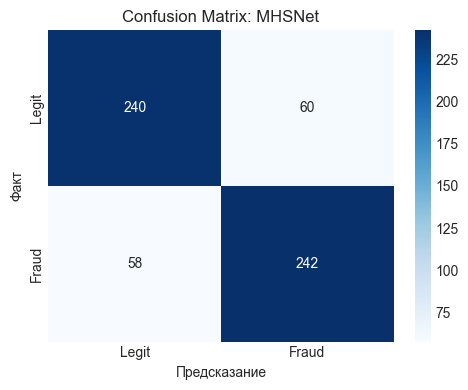

In [12]:
# Матрица ошибок MHSNet
cm = confusion_matrix(data["y_test"], y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], ax=ax)
ax.set_xlabel("Предсказание")
ax.set_ylabel("Факт")
ax.set_title("Confusion Matrix: MHSNet")
plt.tight_layout()
plt.savefig(config.output_dir / "confusion_mhsnet.png", dpi=150)
plt.show()

<a id="10"></a>
## 10. Эксперименты и сравнение с baseline

Сравниваем MHSNet с:
- **Logistic Regression** — линейный supervised baseline
- **Random Forest** — сильный supervised baseline
- **Isolation Forest** — unsupervised аналог LOF

In [13]:
# Baseline обучаются в том же пространстве признаков (после Kernel PCA)
X_train_proj = detector._transform_features(data["X_train"])
X_test_proj = detector._transform_features(data["X_test"])

baselines = train_baselines(X_train_proj, data["y_train"], random_state=config.random_state)
baseline_results = predict_baselines(baselines, X_test_proj)

all_results = {"mhsnet": mhs_metrics}
predictions = {"mhsnet": y_pred}
scores_dict = {"mhsnet": y_score}

for result in baseline_results:
    all_results[result.name] = compute_metrics(
        data["y_test"], result.y_pred, result.y_score
    )
    predictions[result.name] = result.y_pred
    scores_dict[result.name] = result.y_score

results_df = metrics_to_dataframe(all_results).round(4)
display(results_df)

,accuracy,precision,recall,f1,roc_auc,recall_at_fpr_5
mhsnet,0.8033,0.8013,0.8067,0.8040,0.8963,0.6167
logistic_regression,0.9017,0.9228,0.8767,0.8991,0.9699,0.8233
random_forest,0.9200,0.9737,0.8633,0.9152,0.9824,0.9300
isolation_forest,0.8067,0.7556,0.9067,0.8242,0.8684,0.2400


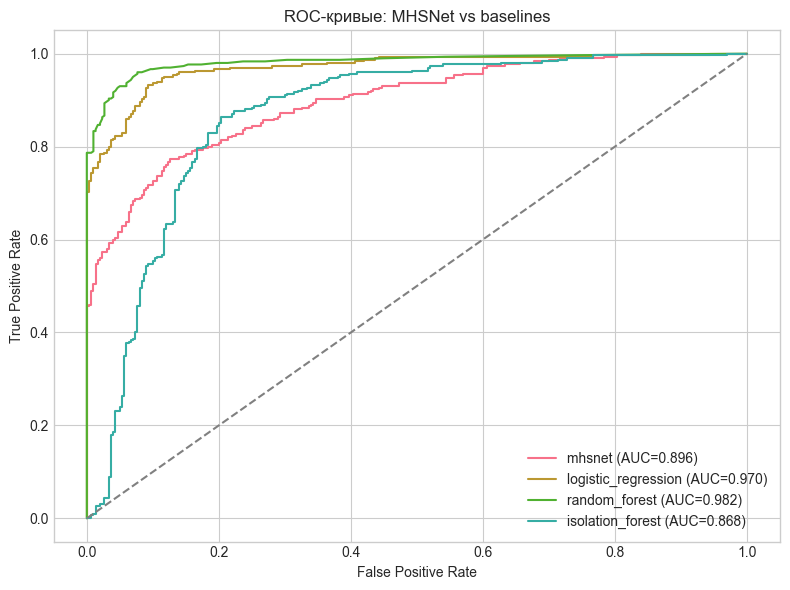

In [14]:
# ROC-кривые
fig, ax = plt.subplots(figsize=(8, 6))
y_test = data["y_test"]

for name, sc in scores_dict.items():
    fpr, tpr, _ = roc_curve(y_test, sc)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые: MHSNet vs baselines")
ax.legend()
plt.tight_layout()
plt.savefig(config.output_dir / "roc_curves.png", dpi=150)
plt.show()

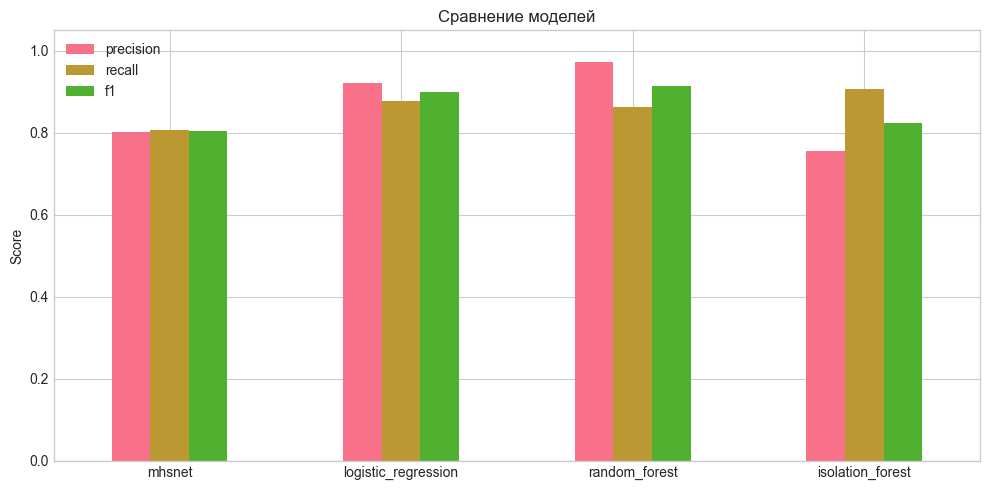


Результаты сохранены в: C:\my_work_repo\hopfield-network-for-fraud-nir\outputs\notebook_run


In [15]:
# Столбчатая диаграмма F1 / Recall / Precision
plot_df = results_df[["precision", "recall", "f1"]]
ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение моделей")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(config.output_dir / "metrics_comparison.png", dpi=150)
plt.show()

# Сохранение результатов
results_df.to_csv(config.output_dir / "metrics.csv")
with open(config.output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in all_results.items()}, f, indent=2)

print(f"\nРезультаты сохранены в: {config.output_dir}")

### Абляционный эксперимент (опционально)

Для НИР полезно показать вклад каждого этапа. Раскомментируйте и запустите:

In [16]:
# # Абляция: отключаем Kernel PCA и/или LOF
# ablation_configs = [
#     ("Полный MHSNet", dict(use_kernel_pca=True, use_lof=True)),
#     ("Без KPCA",       dict(use_kernel_pca=False, use_lof=True)),
#     ("Без LOF",        dict(use_kernel_pca=True, use_lof=False)),
#     ("Только Hopfield", dict(use_kernel_pca=False, use_lof=False)),
# ]
#
# ablation_rows = []
# for name, overrides in ablation_configs:
#     cfg = ExperimentConfig(**{**config.__dict__, **overrides})
#     det = MHSNetFraudDetector(cfg)
#     det.fit(data["X_train"], data["y_train"])
#     det.tune_thresholds(data["X_val"], data["y_val"])
#     pred = det.predict(data["X_test"])
#     sc = det.predict_scores(data["X_test"])
#     m = compute_metrics(data["y_test"], pred, sc)
#     ablation_rows.append({"config": name, **m})
#
# display(pd.DataFrame(ablation_rows).round(4))

<a id="11"></a>
## 11. Выводы

### 11.1. Основные результаты

1. **Реализован пайплайн MHSNet** по схеме Zhao et al. (SSRN 5335578): Kernel PCA → LOF → Hopfield (MHS).
2. **Kernel PCA** выявляет нелинейную структуру данных и улучшает разделимость классов в проекции.
3. **LOF** обеспечивает безучительный первый этап фильтрации аномалий по локальной плотности.
4. **Сеть Хопфилда** с Modern Hopfield Energy работает как ассоциативная память нормальных транзакций; высокий аномальный скор коррелирует с fraud.
5. **Supervised-методы** (Random Forest, Logistic Regression) превосходят unsupervised-подход по F1 — это ожидаемо при наличии разметки.
6. **MHSNet** сопоставим с Isolation Forest по классу подхода (anomaly detection), но использует теоретически обоснованную энергетическую модель Хопфилда.

### 11.2. Ограничения

- Kernel PCA имеет сложность $O(n^2)$ — для больших выборок используется подвыборка при обучении.
- Ёмкость классической сети Хопфилда ограничена (~$0.14N$ паттернов) — применяется K-means для выбора прототипов.
- SNN из оригинальной статьи не реализован (упрощение для бакалаврской НИР).
- Метрики зависят от сбалансированности тестовой выборки.

### 11.3. Направления дальнейших исследований

- Полная реализация SNN-ветки MHSNet.
- Онлайн-обучение прототипов (адаптация к concept drift).
- Интеграция с правилами банка (гибридный supervised + unsupervised).
- Оценка на потоковых данных в режиме, близком к real-time.

### 11.4. Литература

1. Zhao Y. MHSNet-SNN: Improved Outlier Detection for Fraud Detection in Financial Transactions. SSRN 5335578, 2025.
2. Hopfield J.J. Neural networks and physical systems with emergent collective computational abilities. PNAS, 1982.
3. Ramsauer H. et al. Hopfield Networks is All You Need. ICLR, 2021.
4. Breunig M. et al. LOF: Identifying Density-Based Local Outliers. SIGMOD, 2000.
5. Schölkopf B. et al. Kernel Principal Component Analysis. ICANN, 1998.